# Quality Assessment
Now it's your turn. Follow the steps on the platform and use what you've learnt to see how reliable the data is.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
orders_q= pd.read_csv('../data/orders_rev2.csv')
orderlines_q = pd.read_csv('../data/orderlines_rev2.csv')
products_q = pd.read_csv('../data/products_rev2.csv')
orders_q["created_date"] = pd.to_datetime(orders_q["created_date"])

In [6]:
orders_orderlines_q = orders_q[['order_id', 'created_date', 'total_paid']].merge(orderlines_q[['id_order', 'unit_price', 'date', 'sku']] , left_on='order_id', right_on='id_order', how='left' )
products_orders_orderlines_q = orders_orderlines_q.merge(products_q[['sku', 'brand', 'state', 'name', 'desc', 'price', 'category', 'primary', 'secondary' ]], left_on='sku', right_on='sku') 
products_orders_orderlines_q#.unit_price.nlargest(20).value_counts()

,order_id,created_date,total_paid,id_order,unit_price,date,sku,brand,state,name,desc,price,category,primary,secondary
0,241423,2017-11-06 13:10:02,136.15,241423,129.16,2017-11-06 12:47:20,LAC0212,LAC,new,LaCie Porsche Design Desktop Drive 4TB USB 3.0...,External Hard Drive 4TB 35-inch USB 3.0 for Ma...,139.99,drive,usb,drive
1,242832,2017-12-31 17:40:03,15.76,242832,10.77,2017-12-31 17:26:40,PAR0074,PAR,new,Parrot 550mAh battery for MiniDrones,550mAh rechargeable battery for Parrot minidrones,17.99,ipad,iphone,ipad
2,243330,2017-02-16 10:59:38,84.98,243330,77.99,2017-02-15 17:07:44,OWC0074,OWC,new,Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM,8GB RAM Mac mini iMac MacBook and MacBook Pro ...,99.99,memory,mac,memory
3,245275,2017-06-28 11:35:37,149.00,245275,149.00,2017-06-28 11:12:30,TAD0007,TAD,new,Tado Smart Climate Control Intelligent AC,intelligent control air conditioning works wit...,179.00,ipad,iphone,ipad
4,245595,2017-01-21 12:52:47,112.97,245595,52.99,2017-01-21 12:49:00,PAC1561,PAC,new,"Macally External Hard Drive 1TB 35 ""USB 3.0 SA...",Aluminum External Hard Drive 1TB capacity form...,103.95,drive,usb,drive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54099,527042,2018-03-14 11:47:50,18.98,527042,13.99,2018-03-14 11:42:38,APP0927,APP,new,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...,35.00,headphones,headphones,iphone
54100,527070,2018-03-14 11:50:48,24.97,527070,9.99,2018-03-14 11:49:01,APP0698,APP,new,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,cable,cable,lightning
54101,527074,2018-03-14 11:51:42,24.97,527074,9.99,2018-03-14 11:49:36,APP0698,APP,new,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,cable,cable,lightning
54102,527096,2018-03-14 11:58:40,34.96,527096,9.99,2018-03-14 11:54:35,APP0698,APP,new,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,cable,cable,lightning


Congratulations! We have amaizing data, we can try to plot something now...

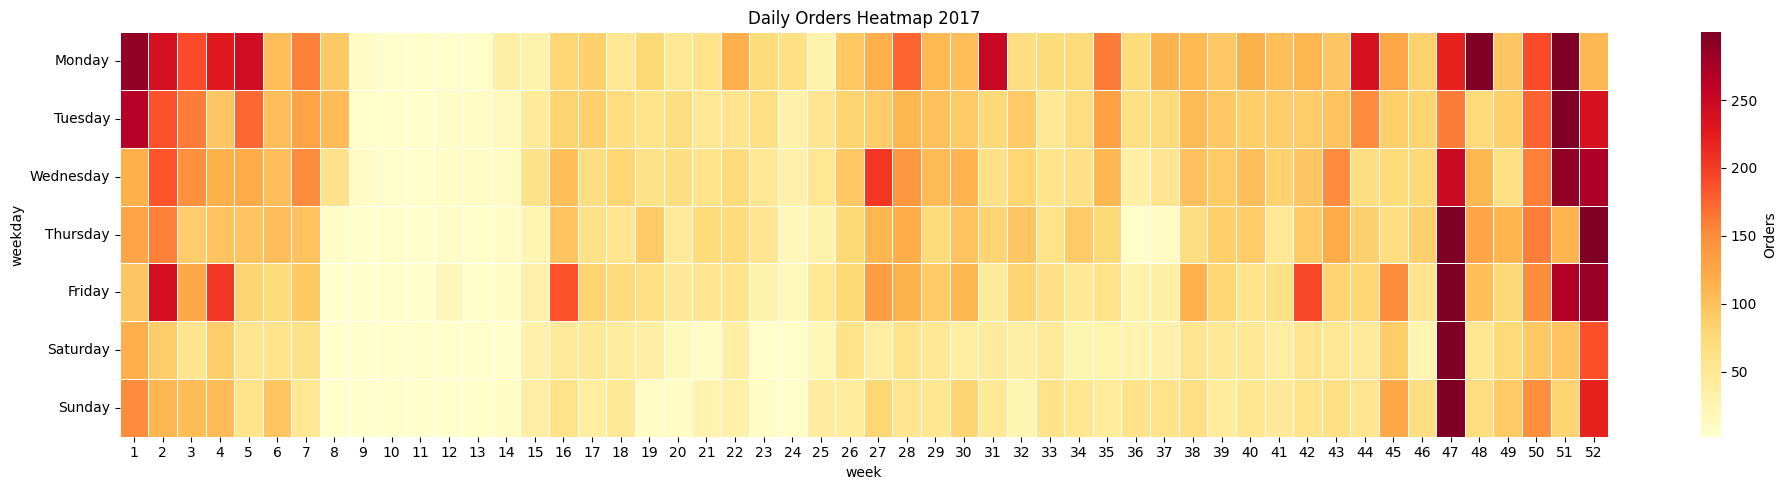

In [7]:
daily = orders_q.resample('D', on='created_date').count()['order_id']

df_heat = pd.DataFrame({'count': daily})
df_heat['weekday'] = daily.index.day_name()
df_heat['week'] = daily.index.isocalendar().week.astype(int)
df_heat['year'] = daily.index.year

df_heat = df_heat[df_heat['year'] == 2017]  # ← filter here

pivot = df_heat.pivot_table(index='weekday', columns='week', values='count', aggfunc='sum')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(20, 5))
#sns.heatmap(pivot, cmap='tab20', linewidths=0.5, cbar_kws={'label': 'Orders'})
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, 
            robust=True,  # ignores outliers for color scaling
            cbar_kws={'label': 'Orders'})
plt.title('Daily Orders Heatmap 2017')
plt.tight_layout()
plt.show()

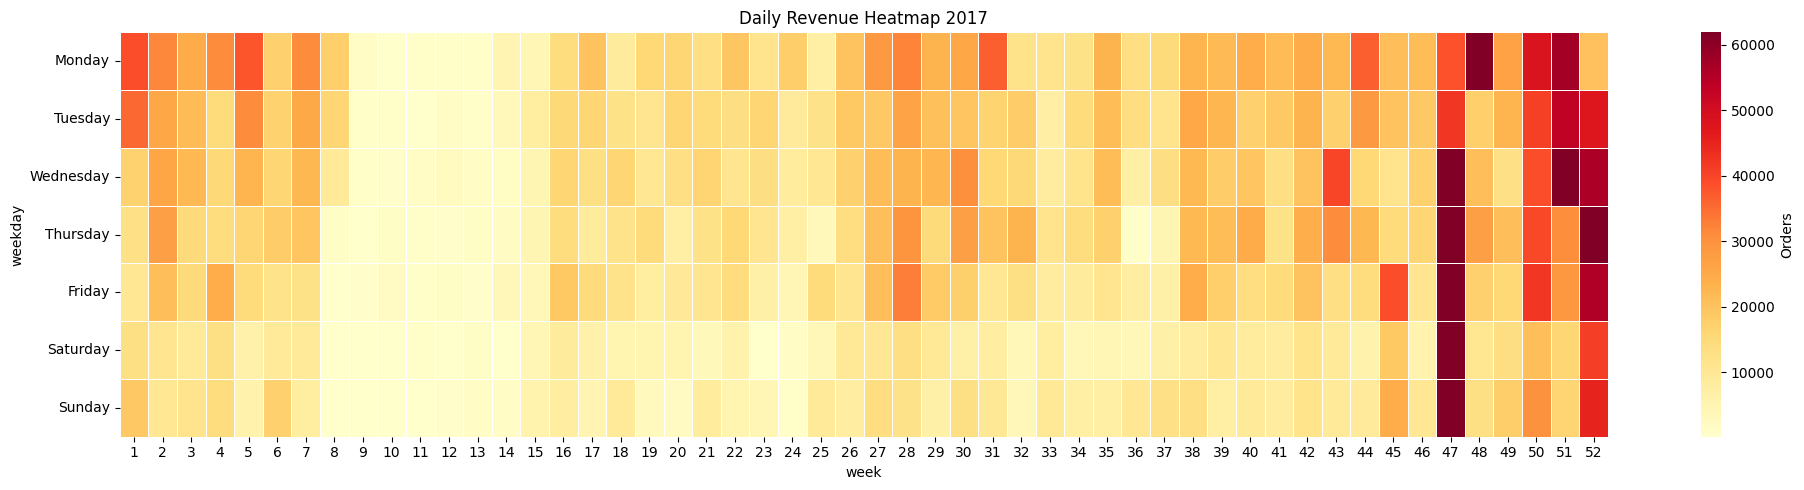

In [8]:
daily = orders_q.resample('D', on='created_date').sum()['total_paid']

df_heat2 = pd.DataFrame({'sum': daily})
df_heat2['weekday'] = daily.index.day_name()
df_heat2['week'] = daily.index.isocalendar().week.astype(int)
df_heat2['year'] = daily.index.year

df_heat2 = df_heat2[df_heat2['year'] == 2017]  # ← filter here

pivot = df_heat2.pivot_table(index='weekday', columns='week', values='sum', aggfunc='sum')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(20, 5))
#sns.heatmap(pivot, cmap='tab20', linewidths=0.5, cbar_kws={'label': 'Orders'})
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, 
            robust=True,  # ignores outliers for color scaling
            cbar_kws={'label': 'Orders'})
plt.title('Daily Revenue Heatmap 2017')
plt.tight_layout()
plt.show()

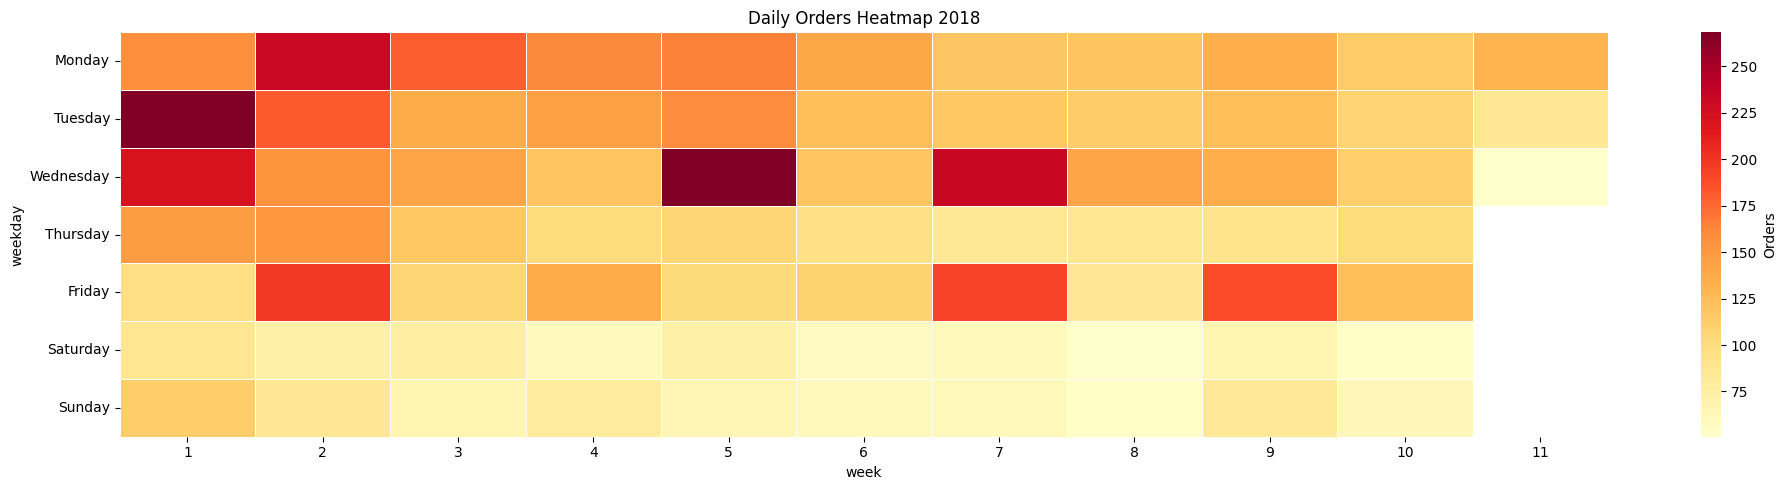

In [9]:
daily = orders_q.resample('D', on='created_date').count()['order_id']

df_heat = pd.DataFrame({'count': daily})
df_heat['weekday'] = daily.index.day_name()
df_heat['week'] = daily.index.isocalendar().week.astype(int)
df_heat['year'] = daily.index.year

df_heat = df_heat[df_heat['year'] == 2018]  # ← filter here

pivot = df_heat.pivot_table(index='weekday', columns='week', values='count', aggfunc='sum')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(20, 5))
#sns.heatmap(pivot, cmap='tab20', linewidths=0.5, cbar_kws={'label': 'Orders'})
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, 
            robust=True,  # ignores outliers for color scaling
            cbar_kws={'label': 'Orders'})
plt.title('Daily Orders Heatmap 2018')
plt.tight_layout()
plt.show()

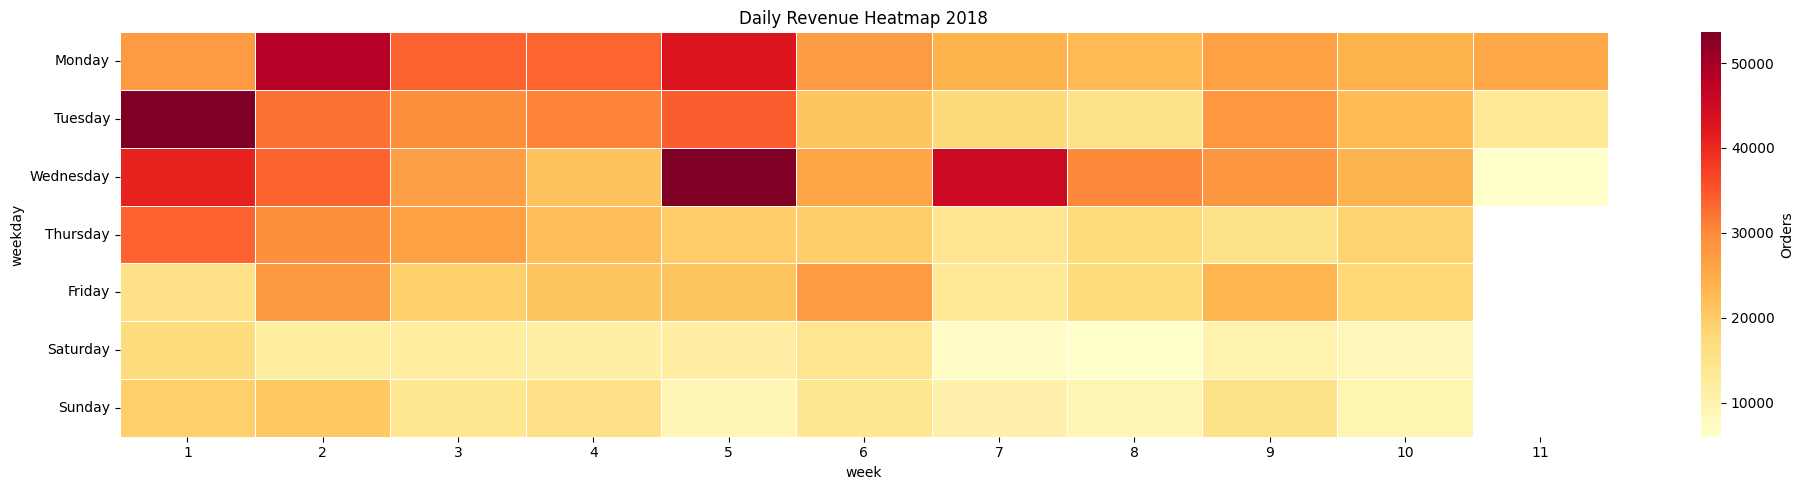

In [10]:
daily = orders_q.resample('D', on='created_date').sum()['total_paid']

df_heat2 = pd.DataFrame({'sum': daily})
df_heat2['weekday'] = daily.index.day_name()
df_heat2['week'] = daily.index.isocalendar().week.astype(int)
df_heat2['year'] = daily.index.year

df_heat2 = df_heat2[df_heat2['year'] == 2018]  # ← filter here

pivot = df_heat2.pivot_table(index='weekday', columns='week', values='sum', aggfunc='sum')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(20, 5))
#sns.heatmap(pivot, cmap='tab20', linewidths=0.5, cbar_kws={'label': 'Orders'})
sns.heatmap(pivot,  cmap='YlOrRd', linewidths=0.5, # annot=True,
            robust=True,  # ignores outliers for color scaling
            cbar_kws={'label': 'Orders'})
plt.title('Daily Revenue Heatmap 2018')
plt.tight_layout()
plt.show()

In [11]:
df_data = df_heat.merge(df_heat2)
df_data

,count,weekday,week,year,sum
0,158,Monday,1,2018,27625.53
1,409,Tuesday,1,2018,76362.99
2,222,Wednesday,1,2018,40937.85
3,148,Thursday,1,2018,34009.55
4,97,Friday,1,2018,15541.39
...,...,...,...,...,...
68,54,Saturday,10,2018,8696.05
69,63,Sunday,10,2018,9482.44
70,130,Monday,11,2018,25381.93
71,86,Tuesday,11,2018,13381.64


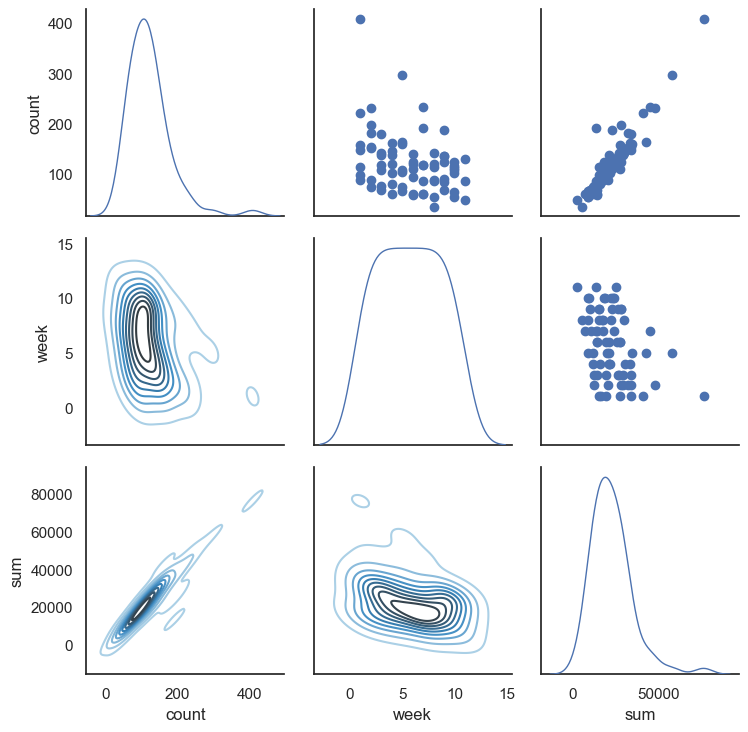

In [12]:
sns.set_theme(style = "white")
df = df_data.loc[:,["count","week","sum"]]
g = sns.PairGrid(df,diag_sharey = False,)
g.map_lower(sns.kdeplot,cmap="Blues_d")
g.map_upper(plt.scatter)
g.map_diag(sns.kdeplot,lw =1)
plt.show()

## 5.&nbsp; Become confident about your dataset

Let's hear your thoughts about what you discovered.

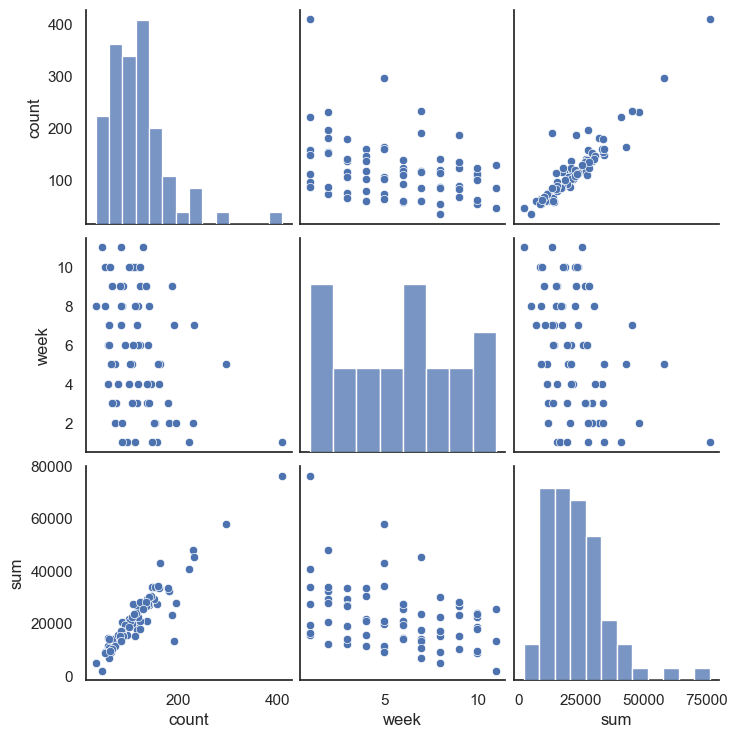

In [13]:
sns.set_theme(style = "white")
df = df_data.loc[:,["count","week","sum"]]
g = sns.pairplot(df,)

Do not forget to download your quality controlled DataFrames

In [14]:
#from google.colab import files

#orders_quality_controlled.to_csv("orders_qu.csv", index=False)
#files.download("orders_qu.csv")

#orderlines_quality_controlled.to_csv("orderlines_qu.csv", index=False)
#files.download("orderlines_qu.csv")